In [1]:
# Librerías
import numpy as np
import os
from PIL import Image

In [2]:
# Establecer ruta correspondiente
path = "17flowers"

En el siguiente enlace encontrará la base de datos y el tipo de flor de cada categoría

[Categorías](https://www.robots.ox.ac.uk/~vgg/data/flowers/17/index.html)

Clase 0


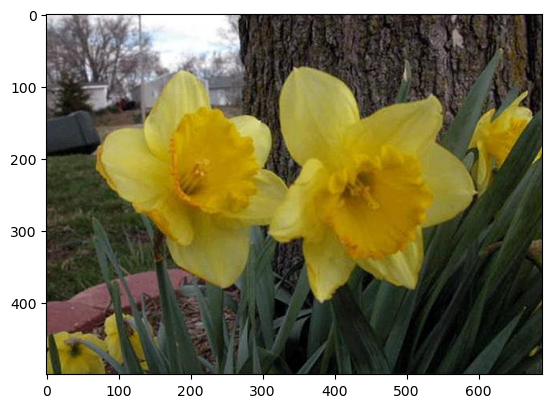

Clase 1


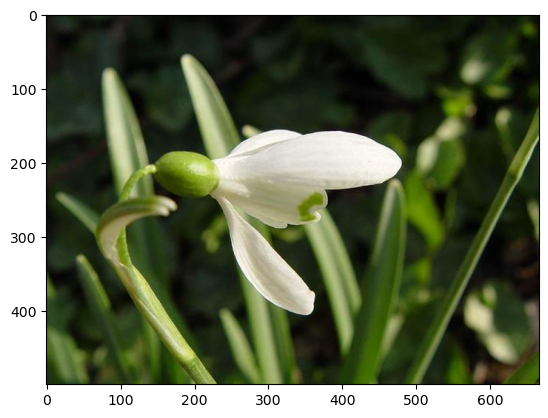

Clase 2


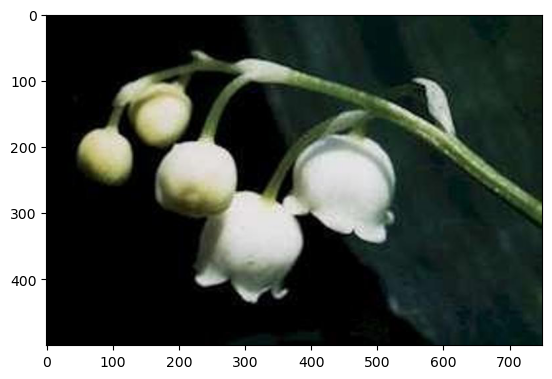

Clase 3


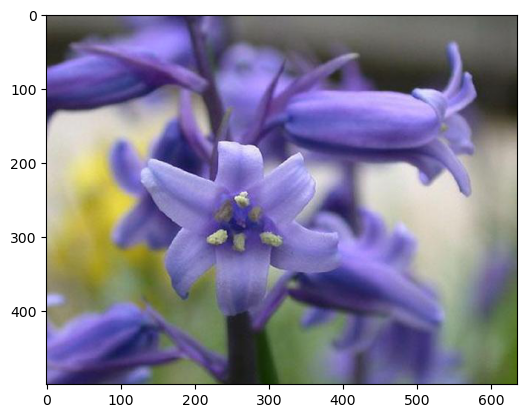

Clase 4


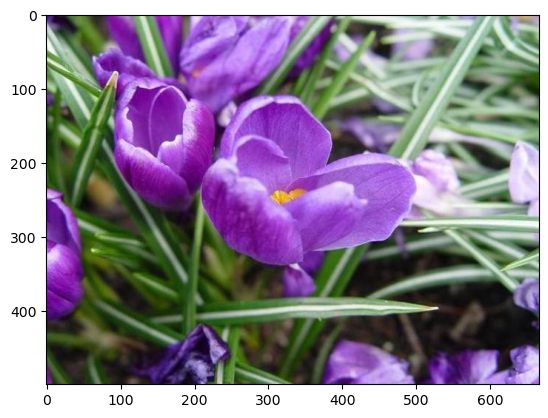

Clase 5


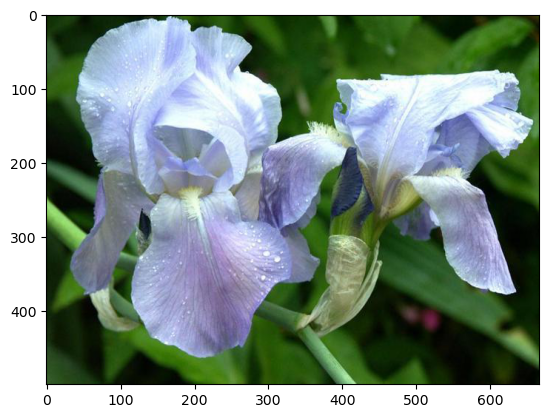

Clase 6


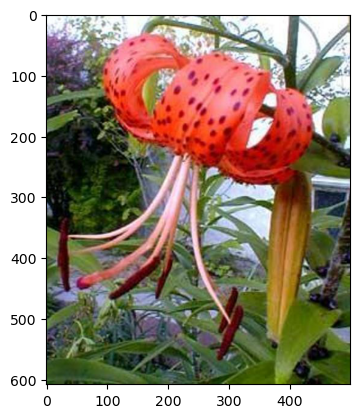

Clase 7


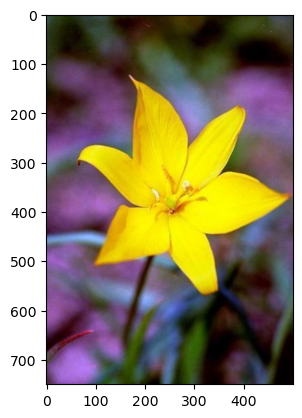

Clase 8


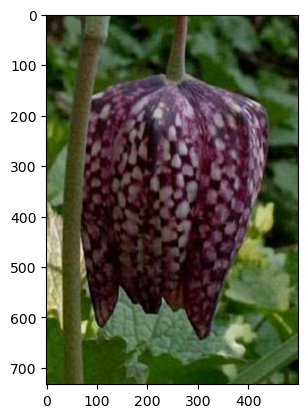

Clase 9


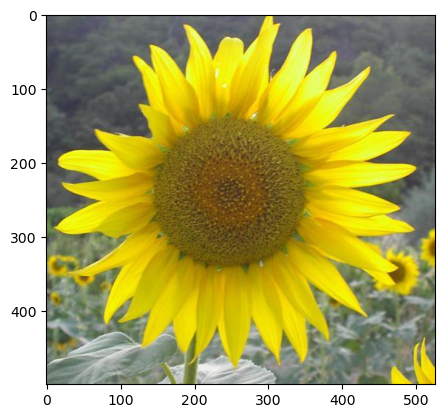

Clase 10


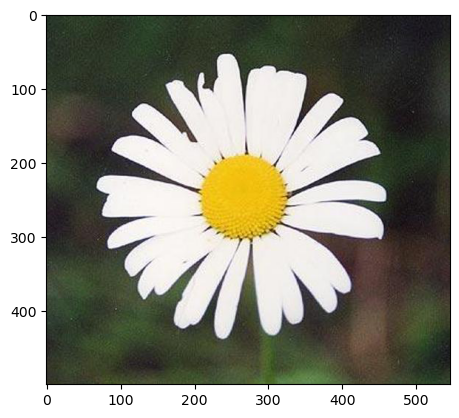

Clase 11


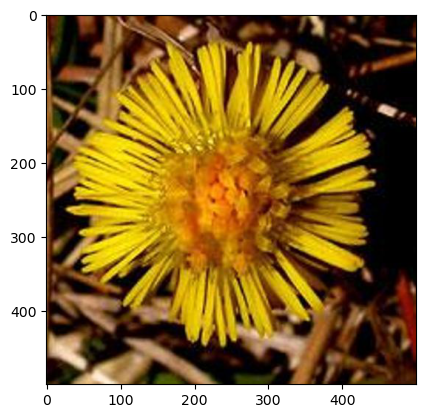

Clase 12


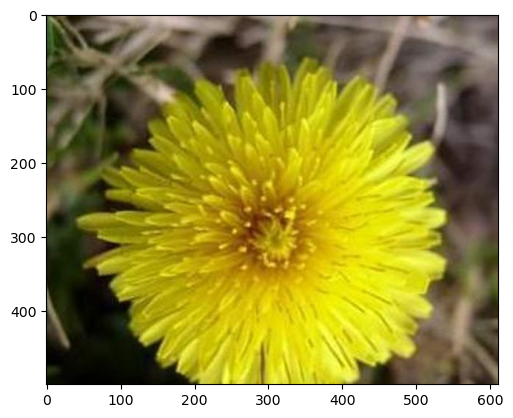

Clase 13


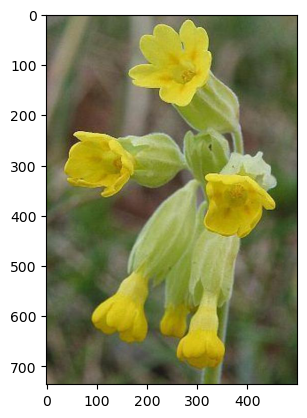

Clase 14


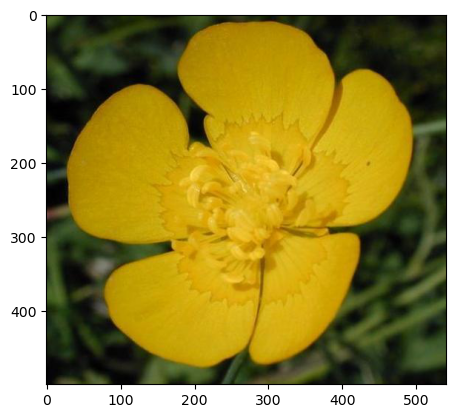

Clase 15


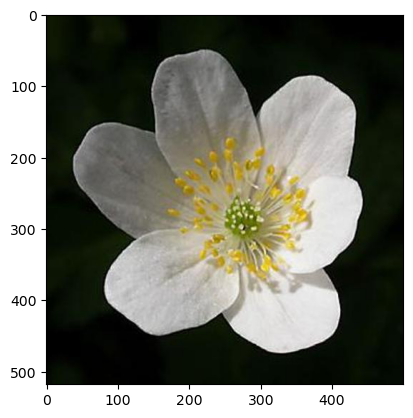

Clase 16


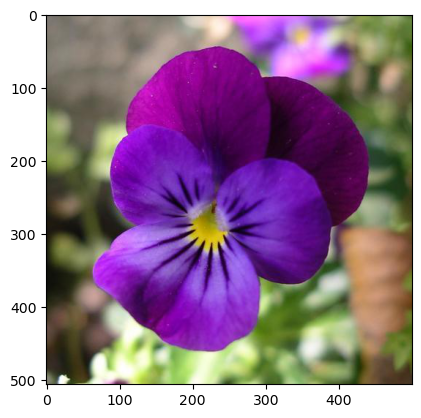

In [3]:
from matplotlib.pyplot import imshow
import matplotlib.pyplot as plt

for i in range(17):
    j = i*80
    name_file = f"{path}\\jpg\\image_{j+1:04d}.jpg"
    img = Image.open(name_file)
    print(f"Clase {i}")
    imshow(np.asarray(img))
    plt.show()

In [4]:
# Elegir las clases correspondientes, enteros entre 0 y 16
classes = [3, 4, 5, 6, 12]
tamano_imagen = 32

In [5]:
# Extraer las imágenes correspondientes a las clases seleccionadas
n_per_class = 80
images = []
images_resized = []
labels = []
target_size = (tamano_imagen, tamano_imagen)
for c in classes:
    start = c * n_per_class
    end = (c + 1) * n_per_class
    for i in range(start, end):
        name_file = f"{path}\\jpg\\image_{i+1:04d}.jpg"
        img = Image.open(name_file)
        images.append(img)
        img_resized = img.convert("RGB").resize(target_size)
        images_resized.append(img_resized)
        labels.append(c)

In [6]:
# Mapear las etiquetas a valores entre 0 y len(classes)-1

# Crear un diccionario que mapea las etiquetas originales a nuevas etiquetas consecutivas
label_map = {original: new for new, original in enumerate(classes)}

# Reemplazar las etiquetas originales en la lista 'labels' con las nuevas etiquetas
labels = [label_map[label] for label in labels]

# Convertir la lista de etiquetas a un arreglo de NumPy para facilitar su manipulación
labels = np.array(labels)

In [7]:
print(f"Cada imagen tiene {tamano_imagen}x{tamano_imagen} pixeles y 3 canales (RGB)")
print(f"Total de atributos por imagen: {tamano_imagen * tamano_imagen * 3}")

Cada imagen tiene 32x32 pixeles y 3 canales (RGB)
Total de atributos por imagen: 3072


## **Ejemplo de imagenes**

In [ ]:
# from PIL import Image
# from IPython.display import Image as IPImage, display

# # Create a list of frames for the GIF
# frames = [img for img in images_resized[:len(images_resized)]]

# # Save the frames as an animated GIF
# gif_path = "animated_images.gif"
# frames[0].save(
#     gif_path,
#     save_all=True,
#     append_images=frames[1:],
#     duration=100,  # Duration in milliseconds for each frame
#     loop=0  # Loop forever
# )

# # Display the GIF in the notebook 
# display(IPImage(gif_path, width=600, height=600))

# https://www.youtube.com/watch?v=7v72Vk0O8T0 # me encanta!

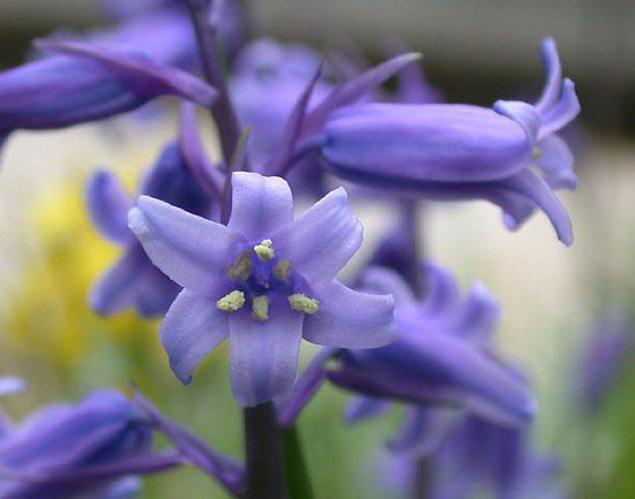

In [ ]:
images[0]

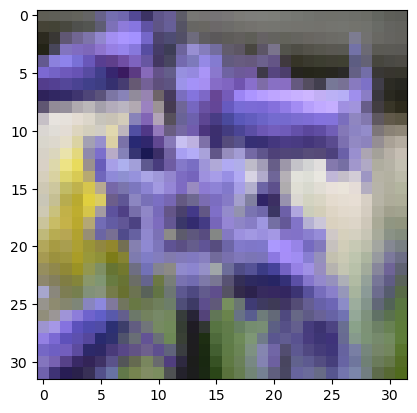

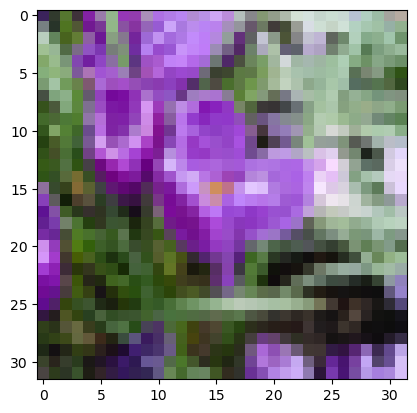

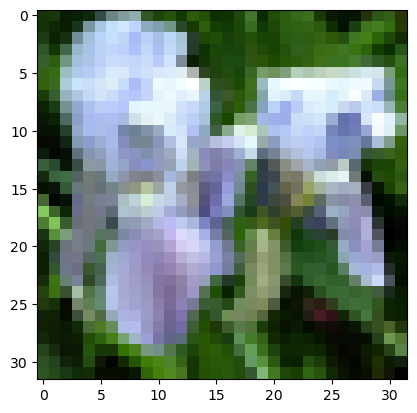

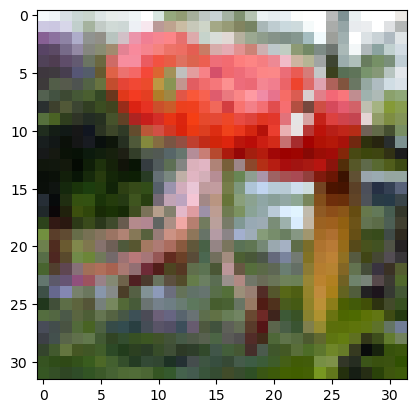

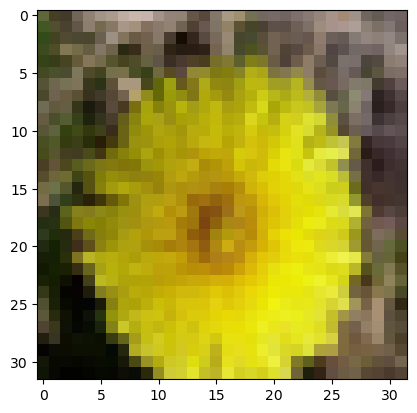

In [54]:
for i in range(len(classes)):
    imshow(np.asarray(images_resized[i*80]))
    plt.show()

## **Poner bonitos los datos**

In [11]:
# Convertir a vector de dimensión 128*128*3=49152 o 64*64*3=12288 y agregar un 1 al final
X = [np.array(img).flatten() for img in images_resized]
X = np.array(X)
X = np.hstack([X, np.ones((X.shape[0], 1))])
X

array([[ 95.,  94.,  85., ..., 106.,  30.,   1.],
       [154., 178., 152., ..., 140.,  69.,   1.],
       [255., 255., 255., ..., 185., 161.,   1.],
       ...,
       [144., 124.,  58., ..., 132.,  56.,   1.],
       [109., 113.,  42., ...,  93.,  80.,   1.],
       [ 41.,  84.,  46., ...,  80.,  57.,   1.]], shape=(400, 3073))

In [12]:
def crearCeros(X):
    """
    Crear un vector de ceros de tamaño igual al número de atributos de X
    """
    zeros = np.zeros((X.shape[1], 1))
    zeros = zeros.flatten()
    return zeros

In [13]:
zeros = crearCeros(X)
zeros.shape

(3073,)

In [14]:
clasificaciones = len(classes)
imagenes = X.shape[0]
dimension = X.shape[1]
filas = clasificaciones - 1
columnas = dimension * (clasificaciones-1) 
pixelesxcanal = dimension - 1
imagesize = int(np.sqrt(int((dimension-1)/3)))

print(f"Clasificaciones: {clasificaciones}")
print(f"Imágenes: \t {imagenes}")
print(f"Dimensión: \t {dimension} \t (Dimensión del vector de cada imagen incluyendo el 1 que absorbe el sesgo)")
print(f"Pixeles x Canal: {pixelesxcanal}")
print(f"Imagen: \t {imagesize}x{imagesize}x3")
print(f"Filas: \t \t {filas} \t (Filas de la construcción de Kessler)")
print(f"Columnas: \t {columnas} \t (Columnas para la construcción de Kessler sin incluir la columna del vector correcto)")
print(f"Dim x Clasif: \t {dimension*clasificaciones} \t (Columnas de la construcción de Kessler)")

Clasificaciones: 5
Imágenes: 	 400
Dimensión: 	 3073 	 (Dimensión del vector de cada imagen incluyendo el 1 que absorbe el sesgo)
Pixeles x Canal: 3072
Imagen: 	 32x32x3
Filas: 	 	 4 	 (Filas de la construcción de Kessler)
Columnas: 	 12292 	 (Columnas para la construcción de Kessler sin incluir la columna del vector correcto)
Dim x Clasif: 	 15365 	 (Columnas de la construcción de Kessler)


## **Para una imagen**

In [15]:
def crearVectorCorrecto(nimagen, filas):
    """
    El vector correcto es simplemente el dato repetido 'filas' veces
    """
    return np.tile(X[nimagen], (filas, 1))

In [16]:
def crearColumnas(nimagen, filas, clasificaciones, zeros):
    """
    Crear las otras 'clasificaciones-1' columnas incorrectas
    """
    columnas = []
    for i in range(clasificaciones - 1):
        nuevaColumna = np.tile(zeros, (filas, 1))
        nuevaColumna[i, :] = -X[nimagen]
        columnas.append(nuevaColumna)
    return columnas

In [17]:
def crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k):
    """
    Crear la matriz de la construcción de Kessler para la clase k para una observación dada juntando la columna correcta y las columnas incorrectas
    """
    cols = []
    for j in range(clasificaciones):
        if k == j:
            cols.append(vectorCorrecto)
        else:
            cols.append(columnas[j if j < k else j-1])
    return np.concatenate(cols, axis=1)

In [18]:
nimagen = 0

In [19]:
vectorCorrecto = crearVectorCorrecto(nimagen, filas)
vectorCorrecto

array([[ 95.,  94.,  85., ..., 106.,  30.,   1.],
       [ 95.,  94.,  85., ..., 106.,  30.,   1.],
       [ 95.,  94.,  85., ..., 106.,  30.,   1.],
       [ 95.,  94.,  85., ..., 106.,  30.,   1.]], shape=(4, 3073))

In [20]:
columnas = crearColumnas(nimagen, filas, clasificaciones, zeros)
columnas[0]

array([[ -95.,  -94.,  -85., ..., -106.,  -30.,   -1.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.]], shape=(4, 3073))

In [21]:
columnas[1]

array([[   0.,    0.,    0., ...,    0.,    0.,    0.],
       [ -95.,  -94.,  -85., ..., -106.,  -30.,   -1.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.]], shape=(4, 3073))

In [22]:
k = 4
matrizClaseK = crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k)
matrizClaseK

array([[-95., -94., -85., ..., 106.,  30.,   1.],
       [  0.,   0.,   0., ..., 106.,  30.,   1.],
       [  0.,   0.,   0., ..., 106.,  30.,   1.],
       [  0.,   0.,   0., ..., 106.,  30.,   1.]], shape=(4, 15365))

In [23]:
k = 3
matrizClaseK = crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k)
matrizClaseK

array([[ -95.,  -94.,  -85., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ..., -106.,  -30.,   -1.]], shape=(4, 15365))

In [24]:
k = 0
matrizClaseK = crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k)
matrizClaseK

array([[  95.,   94.,   85., ...,    0.,    0.,    0.],
       [  95.,   94.,   85., ...,    0.,    0.,    0.],
       [  95.,   94.,   85., ...,    0.,    0.,    0.],
       [  95.,   94.,   85., ..., -106.,  -30.,   -1.]], shape=(4, 15365))

# **Para n imágenes**

In [25]:
def crearMatrizKessler(imagenes, filas, clasificaciones, labels, zeros):
    """
    Crear la matriz de Kessler para todas las imágenes
    """
    nimagen = 0
    # Crear el vector correcto para la imagen
    vectorCorrecto = crearVectorCorrecto(nimagen, filas)
    # Crear las columnas para la imagen
    columnas = crearColumnas(nimagen, filas, clasificaciones, zeros)
    # Conseguir la etiqueta k de la imagen
    k = labels[nimagen]
    # Crear la matriz de la clase k
    matrizClaseK = crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k)
    # Si es la primera imagen, inicializar la matrizKessler
    matrizKessler = matrizClaseK

    # Para la imagen 1 hasta la última
    for nimagen in range(1, imagenes):
        # Crear el vector correcto para la imagen
        vectorCorrecto = crearVectorCorrecto(nimagen, filas)
        # Crear las columnas para la imagen
        columnas = crearColumnas(nimagen, filas, clasificaciones, zeros)
        # Conseguir la etiqueta k de la imagen
        k = labels[nimagen]
        # Crear la matriz de la clase k
        matrizClaseK = crearMatrizClaseK(clasificaciones, columnas, vectorCorrecto, k)
        # Agregar la matriz de la clase k a la matriz grande de Kessler
        # Si no es la primera imagen, apilar la matriz de la clase k
        matrizKessler = np.vstack([matrizKessler, matrizClaseK])

    return matrizKessler

In [26]:
imagenes = X.shape[0]
matrizKessler = crearMatrizKessler(imagenes, filas, clasificaciones, labels, zeros)
matrizKessler

array([[95., 94., 85., ...,  0.,  0.,  0.],
       [95., 94., 85., ...,  0.,  0.,  0.],
       [95., 94., 85., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ..., 80., 57.,  1.],
       [ 0.,  0.,  0., ..., 80., 57.,  1.],
       [ 0.,  0.,  0., ..., 80., 57.,  1.]], shape=(1600, 15365))

In [27]:
print(f"Deberia haber {filas * imagenes} filas en la matriz de Kessler")

Deberia haber 1600 filas en la matriz de Kessler


## **Perceptron para la Matriz de Kessler**

In [ ]:
# from sklearn.linear_model import Perceptron as SklearnPerceptron

# # Crear todos los targets con 1
# targets = np.ones((matrizKessler.shape[0],))
# targets.shape

# sklearn_perceptron = SklearnPerceptron(max_iter=10)
# sklearn_perceptron.fit(matrizKessler, targets)

# Nos da error porque necesita al menos dos clases

In [ ]:
def perceptron_one_class(input_matrix: np.ndarray, max_epochs=1000, learning_rate=1.0) -> np.ndarray:
    """
    Implements the perceptron algorithm for a single class.

    Parameters
    ----------
    input_matrix : numpy.ndarray
        The input matrix of shape (n_samples, n_features), where each row represents a sample.
    max_epochs : int, optional
        The maximum number of epochs to train the perceptron (default is 1000).
    learning_rate : float, optional
        The learning rate for weight updates (default is 1.0).

    Returns
    -------
    numpy.ndarray
        The weight vector of shape (n_features,) learned by the perceptron.

    Notes
    -----
    The perceptron algorithm updates the weight vector whenever a misclassification occurs.
    Training stops early if no misclassifications are found in an epoch.

    Examples
    --------
    >>> import numpy as np
    >>> V = np.array([[1, 2, 3], [-1, -2, -3], [0, 0, 0]])
    >>> perceptron_one_class(V, max_epochs=10, learning_rate=0.1)
    array([0.1, 0.2, 0.3])
    """
    # Initialize the weight vector with zeros, with the same number of features as input_matrix
    weights = np.zeros(input_matrix.shape[1], dtype=float)
    
    # Iterate for the specified number of epochs
    for _ in range(max_epochs):
        errors = 0  # Initialize the error counter for this epoch
        
        # Loop through each sample in the input matrix
        for sample in i#nput_matrix:
            # Check if the sample is misclassified (weights @ sample <= 0)
            if weights @ sample <= 0:
                # Update the weight vector using the learning rate and the sample
                weights += learning_rate * sample
                errors += 1  # Increment the error counter
        
        # If no errors occurred during this epoch, stop training early
        if errors == 0:
            break
    
    # Return the learned weight vector
    return weights

## 800 épocas

In [30]:
# Train the perceptron for a single class using the Kessler matrix
weights = perceptron_one_class(matrizKessler, max_epochs=800, learning_rate=1.0)

# Calculate the block size, which is the number of features per class (including bias if present)
block_size = matrizKessler.shape[1] // clasificaciones

# Reshape the weights array into a matrix where each row corresponds to the weights for one class
weight_matrix = weights[:clasificaciones * block_size].reshape(clasificaciones, block_size)

In [31]:
correct_classifications = 0  
correct_per_class = np.zeros(clasificaciones)
total_per_class = np.zeros(clasificaciones)

# Iterate over each image in the dataset
for image_index in range(imagenes):
    # Extract the feature vector for the current image
    image_vector = X[image_index]
    
    # Compute the scores for each class by multiplying the weight matrix with the image vector
    class_scores = weight_matrix @ image_vector
    
    # Determine the class with the highest score (predicted class)
    predicted_class = np.argmax(class_scores)
    
    # Increment the total count for the true class
    true_class = labels[image_index]
    total_per_class[true_class] += 1
    
    # Check if the predicted class matches the true label of the image
    if predicted_class == true_class:
        # Increment the counter for correct classifications
        correct_classifications += 1
        correct_per_class[true_class] += 1

# Calculate accuracy per class
accuracy_per_class = correct_per_class / total_per_class

In [32]:
# Print the total number of correctly classified images out of the total number of images
print(f"Se clasificaron correctamente {correct_classifications} de {imagenes} imágenes")
print(f"Exactitud por clase: {accuracy_per_class}")

Se clasificaron correctamente 400 de 400 imágenes
Exactitud por clase: [1. 1. 1. 1. 1.]


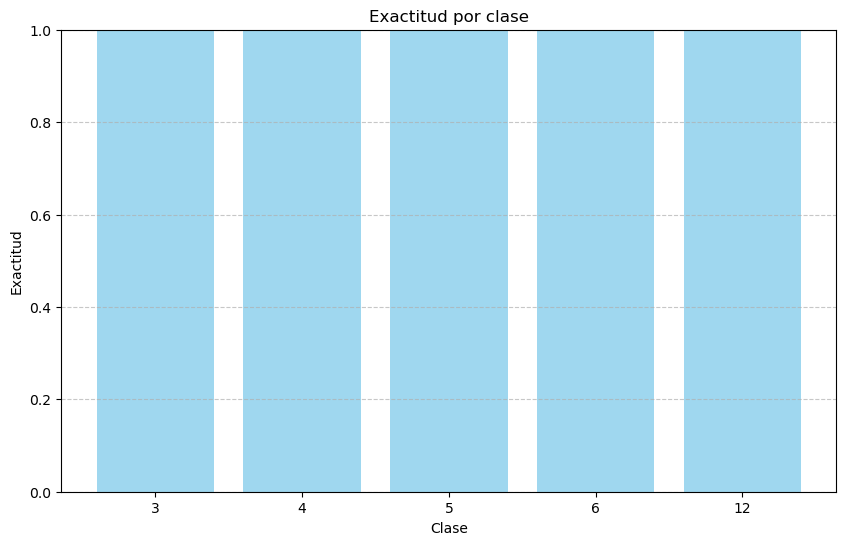

In [33]:
# Plot the accuracy per class
plt.figure(figsize=(10, 6))
plt.bar(range(clasificaciones), accuracy_per_class, color='skyblue', alpha=0.8)
plt.xlabel('Clase')
plt.ylabel('Exactitud')
plt.title('Exactitud por clase')
plt.xticks(range(clasificaciones), classes)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('accuracy_per_class.png')
plt.show()

In [35]:
# Calcula la exactitud del modelo.
exactitud = correct_classifications / imagenes
print(f"Exactitud del modelo: {exactitud*100:.2f}%")

Exactitud del modelo: 100.00%


### 200 épocas

In [36]:
# Train the perceptron for a single class using the Kessler matrix
weights = perceptron_one_class(matrizKessler, max_epochs=200, learning_rate=1.0)

# Calculate the block size, which is the number of features per class (including bias if present)
block_size = matrizKessler.shape[1] // clasificaciones

# Reshape the weights array into a matrix where each row corresponds to the weights for one class
weight_matrix = weights[:clasificaciones * block_size].reshape(clasificaciones, block_size)

In [37]:
correct_classifications = 0  
correct_per_class = np.zeros(clasificaciones)
total_per_class = np.zeros(clasificaciones)

# Iterate over each image in the dataset
for image_index in range(imagenes):
    # Extract the feature vector for the current image
    image_vector = X[image_index]
    
    # Compute the scores for each class by multiplying the weight matrix with the image vector
    class_scores = weight_matrix @ image_vector
    
    # Determine the class with the highest score (predicted class)
    predicted_class = np.argmax(class_scores)
    
    # Increment the total count for the true class
    true_class = labels[image_index]
    total_per_class[true_class] += 1
    
    # Check if the predicted class matches the true label of the image
    if predicted_class == true_class:
        # Increment the counter for correct classifications
        correct_classifications += 1
        correct_per_class[true_class] += 1

# Calculate accuracy per class
accuracy_per_class = correct_per_class / total_per_class

In [38]:
# Print the total number of correctly classified images out of the total number of images
print(f"Se clasificaron correctamente {correct_classifications} de {imagenes} imágenes")
print(f"Exactitud por clase: {accuracy_per_class}")

Se clasificaron correctamente 341 de 400 imágenes
Exactitud por clase: [0.4125 0.925  0.925  1.     1.    ]


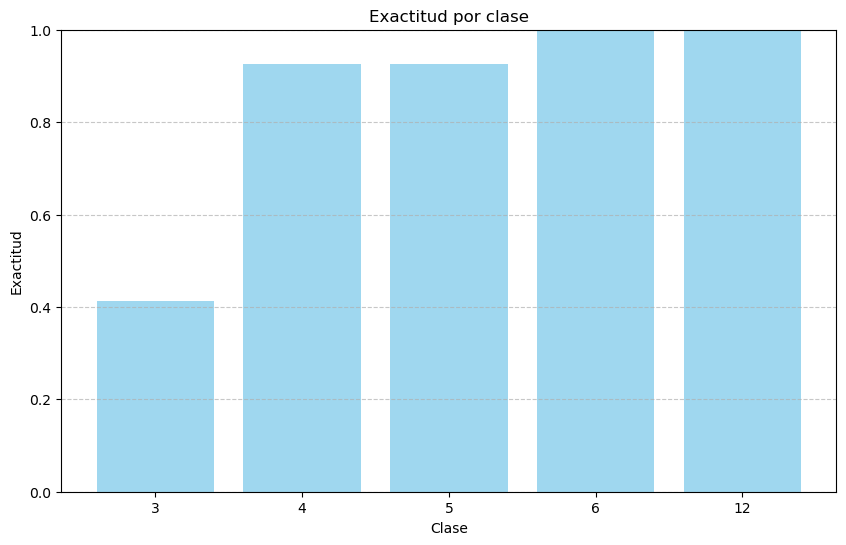

In [39]:
# Plot the accuracy per class
plt.figure(figsize=(10, 6))
plt.bar(range(clasificaciones), accuracy_per_class, color='skyblue', alpha=0.8)
plt.xlabel('Clase')
plt.ylabel('Exactitud')
plt.title('Exactitud por clase')
plt.xticks(range(clasificaciones), classes)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('accuracy_per_class.png')
plt.show()

In [41]:
# Calcula la exactitud del modelo.
exactitud = correct_classifications / imagenes
print(f"Exactitud del modelo: {exactitud*100:.2f}%")

Exactitud del modelo: 85.25%


### 50 épocas

In [42]:
# Train the perceptron for a single class using the Kessler matrix
weights = perceptron_one_class(matrizKessler, max_epochs=50, learning_rate=1.0)

# Calculate the block size, which is the number of features per class (including bias if present)
block_size = matrizKessler.shape[1] // clasificaciones

# Reshape the weights array into a matrix where each row corresponds to the weights for one class
weight_matrix = weights[:clasificaciones * block_size].reshape(clasificaciones, block_size)

In [43]:
correct_classifications = 0  
correct_per_class = np.zeros(clasificaciones)
total_per_class = np.zeros(clasificaciones)

# Iterate over each image in the dataset
for image_index in range(imagenes):
    # Extract the feature vector for the current image
    image_vector = X[image_index]
    
    # Compute the scores for each class by multiplying the weight matrix with the image vector
    class_scores = weight_matrix @ image_vector
    
    # Determine the class with the highest score (predicted class)
    predicted_class = np.argmax(class_scores)
    
    # Increment the total count for the true class
    true_class = labels[image_index]
    total_per_class[true_class] += 1
    
    # Check if the predicted class matches the true label of the image
    if predicted_class == true_class:
        # Increment the counter for correct classifications
        correct_classifications += 1
        correct_per_class[true_class] += 1

# Calculate accuracy per class
accuracy_per_class = correct_per_class / total_per_class

In [44]:
# Print the total number of correctly classified images out of the total number of images
print(f"Se clasificaron correctamente {correct_classifications} de {imagenes} imágenes")
print(f"Exactitud por clase: {accuracy_per_class}")

Se clasificaron correctamente 224 de 400 imágenes
Exactitud por clase: [0.1375 0.35   0.55   0.7625 1.    ]


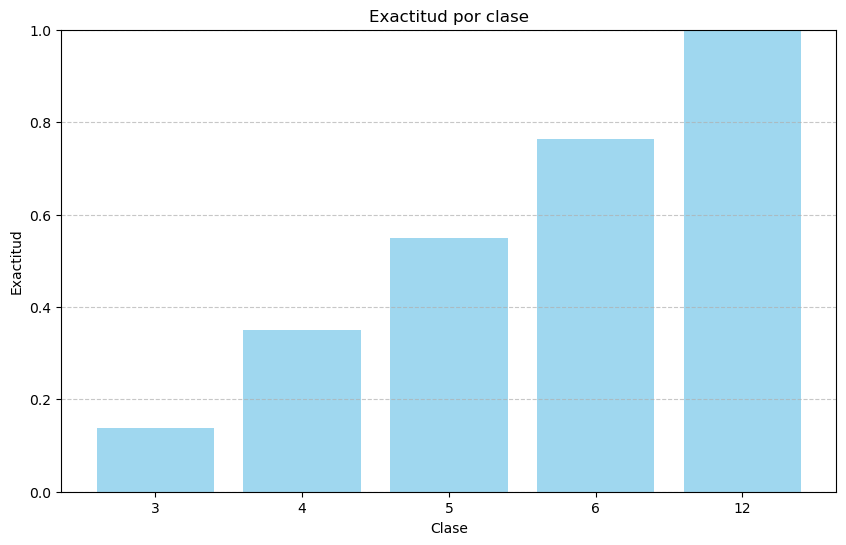

In [45]:
# Plot the accuracy per class
plt.figure(figsize=(10, 6))
plt.bar(range(clasificaciones), accuracy_per_class, color='skyblue', alpha=0.8)
plt.xlabel('Clase')
plt.ylabel('Exactitud')
plt.title('Exactitud por clase')
plt.xticks(range(clasificaciones), classes)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('accuracy_per_class.png')
plt.show()

In [46]:
# Calcula la exactitud del modelo.
exactitud = correct_classifications / imagenes
print(f"Exactitud del modelo: {exactitud*100:.2f}%")

Exactitud del modelo: 56.00%
